Training rows : 432
Test rows     : 27

--- Time Series Cross Validation Results ---
Fold 1  |  Train size: 72  |  Val size: 72  |  MAPE: 4.96%  |  MAE: 600.26  |  R²: 0.5845
Fold 2  |  Train size: 144  |  Val size: 72  |  MAPE: 3.25%  |  MAE: 459.85  |  R²: 0.8374
Fold 3  |  Train size: 216  |  Val size: 72  |  MAPE: 2.39%  |  MAE: 410.07  |  R²: 0.7586
Fold 4  |  Train size: 288  |  Val size: 72  |  MAPE: 2.36%  |  MAE: 491.47  |  R²: 0.5329
Fold 5  |  Train size: 360  |  Val size: 72  |  MAPE: 3.13%  |  MAE: 644.40  |  R²: 0.3246

Mean CV MAPE : 3.22%
Std  CV MAPE : 0.94%
Mean CV MAE  : 521.21
Mean CV R²   : 0.6076

--- Final Test Set Results ---
MAPE : 2.85%
MAE  : 578.58
RMSE : 702.22
R²   : 0.4375


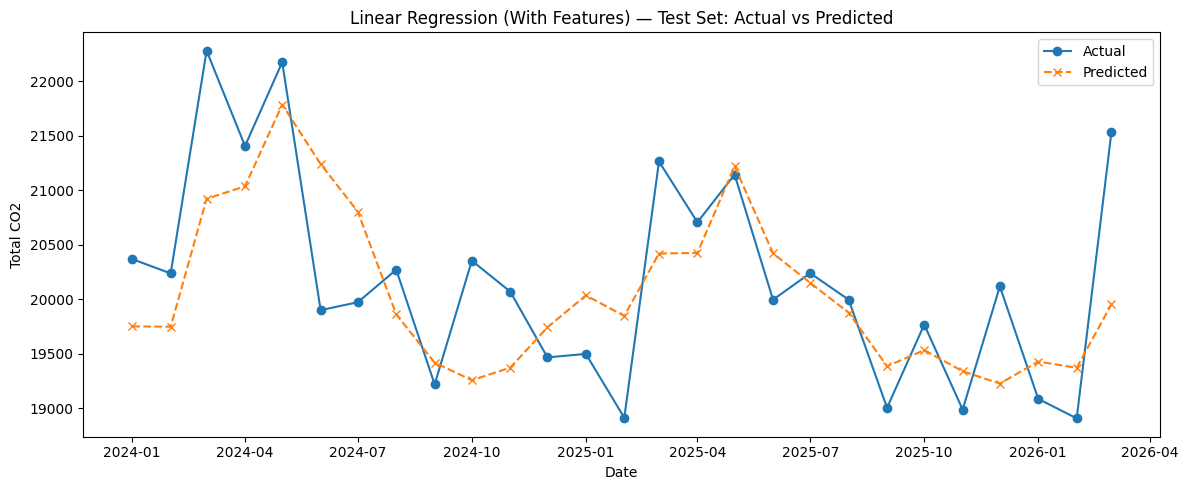

In [14]:
# ============================================================
# LINEAR REGRESSION — WITH TIME SERIES CROSS VALIDATION
# Thailand CO2 Emissions Forecasting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================

df = pd.read_csv('/content/co2_monthly_1987_2026_clean.csv')
monthly = df.groupby(['Year', 'Month'])['Total_CO2'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)

# ============================================================
# STEP 2: FEATURE ENGINEERING
# Done ONCE on full data before any split
# Lags use .shift() so no future values leak into features
# ============================================================

monthly['time_index'] = np.arange(len(monthly))

# Lag features (past values of target only)
monthly['lag_1']  = monthly['Total_CO2'].shift(1)
monthly['lag_2']  = monthly['Total_CO2'].shift(2)
monthly['lag_3']  = monthly['Total_CO2'].shift(3)
monthly['lag_12'] = monthly['Total_CO2'].shift(12)

# Rolling mean features (shift first to avoid current month leaking in)
monthly['rolling_mean_3'] = monthly['Total_CO2'].shift(1).rolling(3).mean()
monthly['rolling_mean_6'] = monthly['Total_CO2'].shift(1).rolling(6).mean()

# Cyclic encoding of month (captures seasonal continuity)
monthly['month_sin'] = np.sin(2 * np.pi * monthly['Month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['Month'] / 12)

# Drop NaN rows created by lag and rolling operations
monthly.dropna(inplace=True)
monthly.reset_index(drop=True, inplace=True)

# ============================================================
# STEP 3: DEFINE X AND Y
# ============================================================

feature_cols = [
    'time_index',
     'lag_1','lag_2', 'lag_3', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6',
    'month_sin', 'month_cos'
]

X = monthly[feature_cols]
Y = monthly['Total_CO2']

# ============================================================
# STEP 4: TRAIN / TEST SPLIT  (chronological, hard boundary)
# Everything before Jan 2024 → training
# Jan 2024 onward → untouched test set
# ============================================================

split_idx = monthly[(monthly['Year'] == 2024) & (monthly['Month'] == 1)].index[0]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")

# ============================================================
# STEP 5: TIME SERIES CROSS VALIDATION ON TRAINING DATA
# Purpose: robust model evaluation across multiple time windows
# NOT random CV — folds always move forward in time
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)
cv_mape_scores = []
cv_mae_scores  = []
cv_r2_scores   = []

print("\n--- Time Series Cross Validation Results ---")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    # Slice fold data
    X_tr_fold = X_train.iloc[train_idx]
    Y_tr_fold = Y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    Y_val_fold = Y_train.iloc[val_idx]

    # Scale inside fold — scaler sees only training fold, not validation
    scaler = StandardScaler()
    X_tr_scaled  = scaler.fit_transform(X_tr_fold)
    X_val_scaled = scaler.transform(X_val_fold)

    # Fit model fresh each fold
    model = LinearRegression()
    model.fit(X_tr_scaled, Y_tr_fold)

    # Predict on validation fold
    preds = model.predict(X_val_scaled)

    # Compute metrics
    mape = mean_absolute_percentage_error(Y_val_fold, preds) * 100
    mae  = mean_absolute_error(Y_val_fold, preds)
    r2   = r2_score(Y_val_fold, preds)

    cv_mape_scores.append(mape)
    cv_mae_scores.append(mae)
    cv_r2_scores.append(r2)

    print(f"Fold {fold+1}  |  Train size: {len(X_tr_fold)}  |  Val size: {len(X_val_fold)}  "
          f"|  MAPE: {mape:.2f}%  |  MAE: {mae:.2f}  |  R²: {r2:.4f}")

print(f"\nMean CV MAPE : {np.mean(cv_mape_scores):.2f}%")
print(f"Std  CV MAPE : {np.std(cv_mape_scores):.2f}%")
print(f"Mean CV MAE  : {np.mean(cv_mae_scores):.2f}")
print(f"Mean CV R²   : {np.mean(cv_r2_scores):.4f}")

# ============================================================
# STEP 6: FINAL MODEL — RETRAIN ON FULL TRAINING DATA
# After CV is done and model is confirmed, retrain on ALL
# training rows before evaluating on test set
# ============================================================

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled  = scaler_final.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_scaled, Y_train)

# ============================================================
# STEP 7: FINAL TEST EVALUATION
# This is the only number that gets reported in the report
# ============================================================

Y_pred_test = final_model.predict(X_test_scaled)

test_mape = mean_absolute_percentage_error(Y_test, Y_pred_test) * 100
test_mae  = mean_absolute_error(Y_test, Y_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_test))
test_r2   = r2_score(Y_test, Y_pred_test)

print("\n--- Final Test Set Results ---")
print(f"MAPE : {test_mape:.2f}%")
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"R²   : {test_r2:.4f}")

# ============================================================
# STEP 8: VISUALISATION — Actual vs Predicted on Test Set
# ============================================================

test_dates = monthly.iloc[split_idx:][['Year', 'Month']].copy()
test_dates['date'] = pd.to_datetime(test_dates.assign(Day=1)[['Year','Month','Day']])

plt.figure(figsize=(12, 5))
plt.plot(test_dates['date'], Y_test.values, label='Actual', marker='o')
plt.plot(test_dates['date'], Y_pred_test,   label='Predicted', marker='x', linestyle='--')
plt.title('Linear Regression (With Features) — Test Set: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Total CO2')
plt.legend()
plt.tight_layout()
plt.show()

In-Sample  MAPE (Train) : 2.80%
Out-Sample MAPE (Test)  : 2.85%
Generalisation Gap      : 0.05%


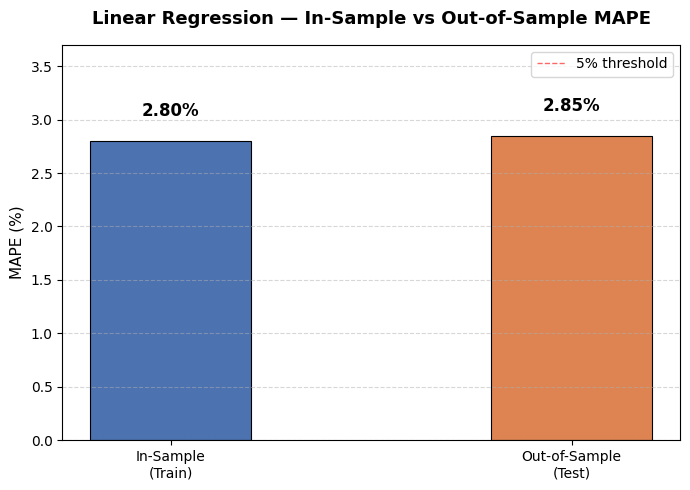

In [15]:
# ============================================================
# IN-SAMPLE vs OUT-OF-SAMPLE MAPE — LINEAR REGRESSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

# ============================================================
# IN-SAMPLE MAPE
# Predict on the same training data the model was fitted on
# This shows how well the model fits what it already saw
# ============================================================

Y_pred_train = final_model.predict(X_train_scaled)

in_sample_mape  = mean_absolute_percentage_error(Y_train, Y_pred_train) * 100
out_sample_mape = mean_absolute_percentage_error(Y_test, Y_pred_test)   * 100

print(f"In-Sample  MAPE (Train) : {in_sample_mape:.2f}%")
print(f"Out-Sample MAPE (Test)  : {out_sample_mape:.2f}%")
print(f"Generalisation Gap      : {out_sample_mape - in_sample_mape:.2f}%")

# ============================================================
# BAR CHART
# ============================================================

labels = ['In-Sample\n(Train)', 'Out-of-Sample\n(Test)']
values = [in_sample_mape, out_sample_mape]
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(labels, values, color=colors, width=0.4, edgecolor='black', linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

ax.set_title('Linear Regression — In-Sample vs Out-of-Sample MAPE',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_ylim(0, max(values) * 1.3)
ax.axhline(y=5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='5% threshold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Metric                     In-Sample   Out-Sample
MAPE (%)                        2.80         2.85
MAE                           413.73       578.58
RMSE                        555.9566     702.2245
MAPE Gap                        0.05%
MAE Gap                       164.85
RMSE Gap                    146.2679


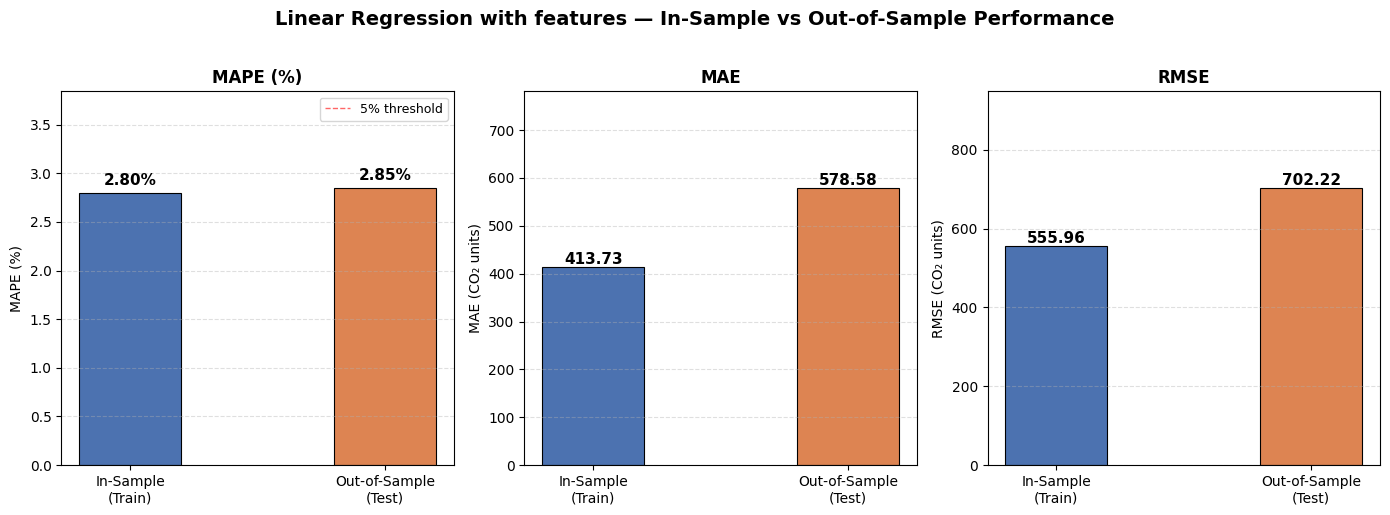

In [16]:
# ============================================================
# IN-SAMPLE vs OUT-OF-SAMPLE — MAPE, MAE, R² + BAR CHARTS
# ============================================================

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# COMPUTE ALL METRICS
# ============================================================

Y_pred_train = final_model.predict(X_train_scaled)
Y_pred_test  = final_model.predict(X_test_scaled)

# MAPE
in_mape  = mean_absolute_percentage_error(Y_train, Y_pred_train) * 100
out_mape = mean_absolute_percentage_error(Y_test,  Y_pred_test)  * 100

# MAE
in_mae  = mean_absolute_error(Y_train, Y_pred_train)
out_mae = mean_absolute_error(Y_test,  Y_pred_test)

# RMSE
in_rmse  = np.sqrt(mean_squared_error(Y_train, Y_pred_train))
out_rmse = np.sqrt(mean_squared_error(Y_test,  Y_pred_test))

print("=" * 50)
print(f"{'Metric':<25} {'In-Sample':>10} {'Out-Sample':>12}")
print("=" * 50)
print(f"{'MAPE (%)':<25} {in_mape:>10.2f} {out_mape:>12.2f}")
print(f"{'MAE':<25} {in_mae:>10.2f} {out_mae:>12.2f}")
print(f"{'RMSE':<25} {in_rmse:>10.4f} {out_rmse:>12.4f}")
print("=" * 50)
print(f"{'MAPE Gap':<25} {out_mape - in_mape:>10.2f}%")
print(f"{'MAE Gap':<25} {out_mae  - in_mae:>10.2f}")
print(f"{'RMSE Gap':<25} {out_rmse - in_rmse:>10.4f}")

# ============================================================
# # BAR CHARTS — One subplot per metric
# ============================================================

labels = ['In-Sample\n(Train)', 'Out-of-Sample\n(Test)']
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Linear Regression with features — In-Sample vs Out-of-Sample Performance',
             fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: MAPE ---
ax1 = axes[0]
values_mape = [in_mape, out_mape]
bars1 = ax1.bar(labels, values_mape, color=colors, width=0.4,
                edgecolor='black', linewidth=0.8)
for bar, val in zip(bars1, values_mape):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('MAPE (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('MAPE (%)', fontsize=10)
ax1.set_ylim(0, max(values_mape) * 1.35)
ax1.axhline(y=5, color='red', linestyle='--', linewidth=1,
            alpha=0.6, label='5% threshold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 2: MAE ---
ax2 = axes[1]
values_mae = [in_mae, out_mae]
bars2 = ax2.bar(labels, values_mae, color=colors, width=0.4,
                edgecolor='black', linewidth=0.8)
for bar, val in zip(bars2, values_mae):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{val:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('MAE', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (CO₂ units)', fontsize=10)
ax2.set_ylim(0, max(values_mae) * 1.35)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# --- Plot 3: RMSE ---
ax3 = axes[2]
values_rmse = [in_rmse, out_rmse]
bars3 = ax3.bar(labels, values_rmse, color=colors, width=0.4,
                edgecolor='black', linewidth=0.8)
for bar, val in zip(bars3, values_rmse):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1,
             f'{val:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_title('RMSE', fontsize=12, fontweight='bold')
ax3.set_ylabel('RMSE (CO₂ units)', fontsize=10)
ax3.set_ylim(0, max(values_rmse) * 1.35)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

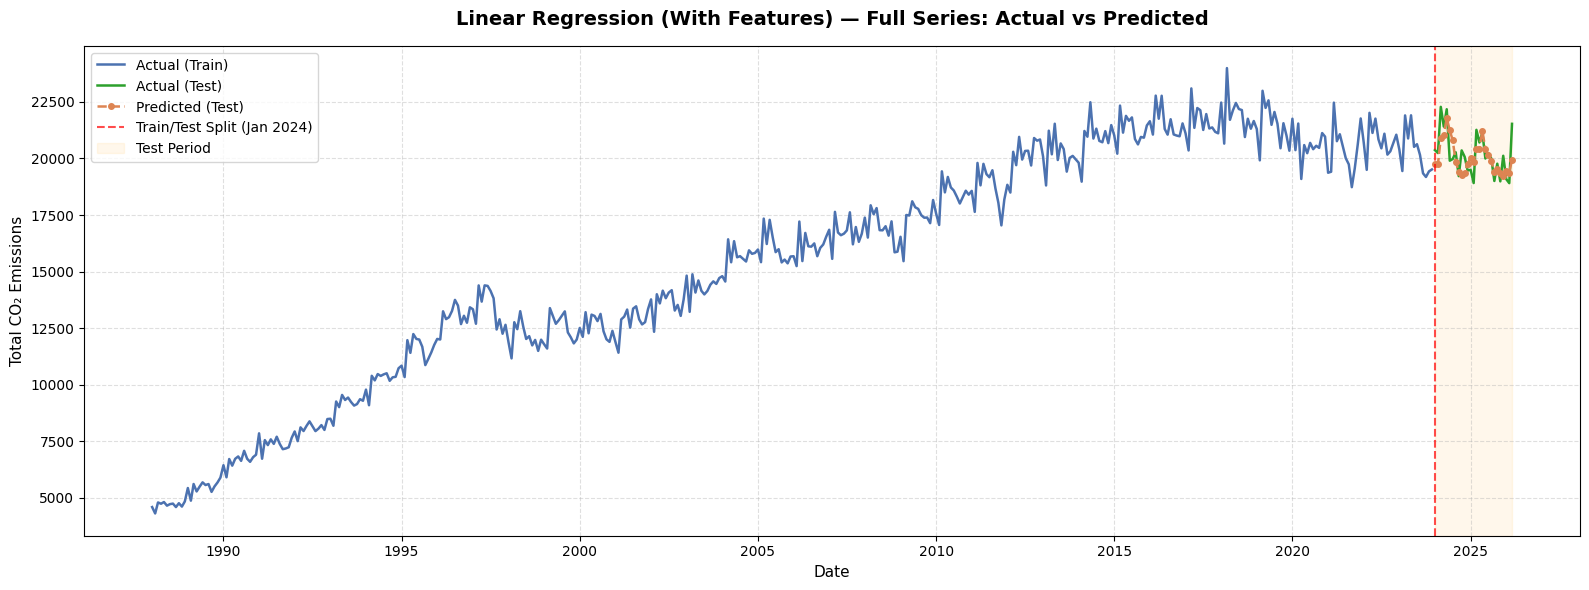

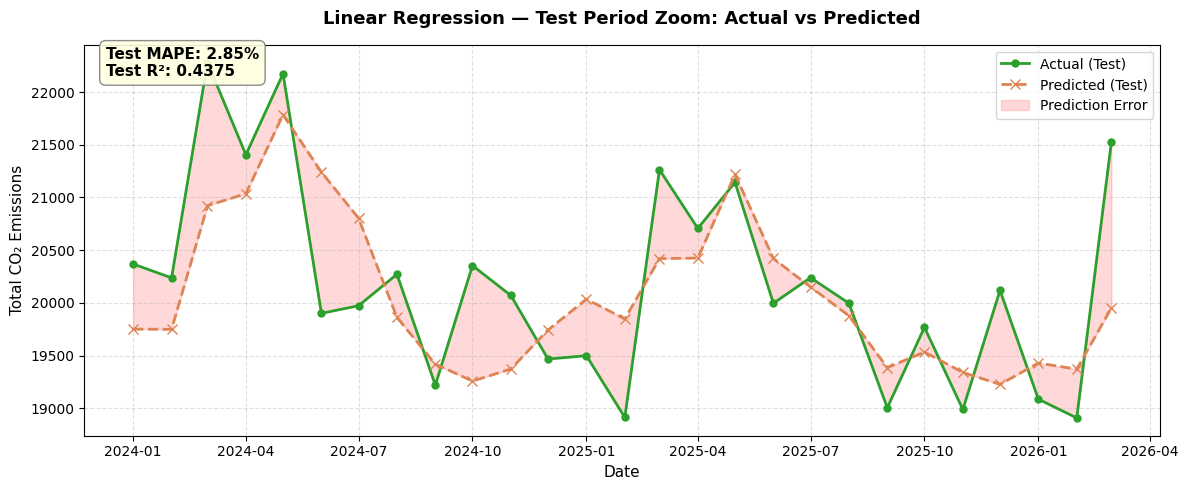

In [17]:
# ============================================================
# FULL SERIES PLOT — TRAIN, TEST, PREDICTED
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# BUILD DATE COLUMN FOR X-AXIS
# ============================================================

monthly['date'] = pd.to_datetime(
    monthly[['Year', 'Month']].assign(Day=1)
)

train_dates = monthly['date'].iloc[:split_idx]
test_dates  = monthly['date'].iloc[split_idx:]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

# --- Train actual ---
ax.plot(train_dates, Y_train.values,
        color='#4C72B0', linewidth=1.8,
        label='Actual (Train)')

# --- Test actual ---
ax.plot(test_dates, Y_test.values,
        color='#2ca02c', linewidth=1.8,
        label='Actual (Test)')

# --- Test predicted ---
ax.plot(test_dates, Y_pred_test,
        color='#DD8452', linewidth=1.8,
        linestyle='--', marker='o', markersize=4,
        label='Predicted (Test)')

# --- Vertical line at train/test boundary ---
split_date = monthly['date'].iloc[split_idx]
ax.axvline(x=split_date, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Train/Test Split (Jan 2024)')

# --- Shaded region for test period ---
ax.axvspan(split_date, test_dates.iloc[-1],
           alpha=0.08, color='orange', label='Test Period')

# --- Annotations ---
ax.set_title('Linear Regression (With Features) — Full Series: Actual vs Predicted',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total CO₂ Emissions', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# ============================================================
# ZOOMED PLOT — TEST PERIOD ONLY
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(test_dates, Y_test.values,
        color='#2ca02c', linewidth=2,
        marker='o', markersize=5,
        label='Actual (Test)')

ax.plot(test_dates, Y_pred_test,
        color='#DD8452', linewidth=2,
        linestyle='--', marker='x', markersize=7,
        label='Predicted (Test)')

# --- Fill between actual and predicted to show error ---
ax.fill_between(test_dates,
                Y_test.values, Y_pred_test,
                alpha=0.15, color='red',
                label='Prediction Error')

# --- Annotate MAPE on plot ---
ax.annotate(f"""Test MAPE: {out_mape:.2f}%
Test R²: {test_r2:.4f}""",
            xy=(0.02, 0.92), xycoords='axes fraction',
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='lightyellow',
                      edgecolor='gray', alpha=0.9))

ax.set_title('Linear Regression — Test Period Zoom: Actual vs Predicted',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total CO₂ Emissions', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='both', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [18]:
# RECURSIVE MULTI-STEP FORECAST — true 27-month horizon, no peeking at actuals
hist = list(Y_train.values)          # known history up to train end
preds_recursive = []
test_rows = monthly.iloc[split_idx:].reset_index(drop=True)

for i in range(len(test_rows)):
    t = test_rows.loc[i]
    feat = {
        'time_index'     : t['time_index'],
        'lag_1'          : hist[-1],
        'lag_2'          : hist[-2],
        'lag_3'          : hist[-3],
        'lag_12'         : hist[-12],
        'rolling_mean_3' : np.mean(hist[-3:]),
        'rolling_mean_6' : np.mean(hist[-6:]),
        'month_sin'      : t['month_sin'],
        'month_cos'      : t['month_cos'],
    }
    x = scaler_final.transform(pd.DataFrame([feat])[feature_cols])
    yhat = final_model.predict(x)[0]
    preds_recursive.append(yhat)
    hist.append(yhat)               # feed prediction back in — this is the key line

rec_mape = mean_absolute_percentage_error(Y_test, preds_recursive) * 100
print(f"Recursive multi-step MAPE: {rec_mape:.2f}%")

Recursive multi-step MAPE: 3.30%


In [19]:
# SEASONAL-NAIVE BASELINE — every model must beat this to justify its existence
naive_pred = monthly['Total_CO2'].shift(12).iloc[split_idx:]
naive_mape = mean_absolute_percentage_error(Y_test, naive_pred) * 100
print(f"Seasonal-naive MAPE: {naive_mape:.2f}%")

Seasonal-naive MAPE: 2.60%
